### Import Libraries

In [47]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
import warnings; warnings.filterwarnings('ignore')
import os

### Load Data

In [48]:
data = pd.read_csv('data/Combined_Housing_Data.csv')
data.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,ContraCosta,ContraCosta,"Carpet,Tile,Wood",NaN,NaN,NaN,False,1998000.0,1150041639,teresa@teresahooper.com,...,NaN,10080.0,NaN,False,3.0,San Ramon Valley,94596,975.0,10080.0,NaN
1,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1150038872,homes@roomsantacruz.com,...,NaN,5663.0,NaN,NaN,5.0,Other,95018,NaN,5663.0,NaN
2,SanDiego,SanDiego,"Carpet,Wood",True,NaN,NaN,False,2214421.0,1150038683,laura@lauralothianrealestate.com,...,NaN,34745.0,NaN,False,3.0,NaN,91364,NaN,34745.0,NaN
3,Mlslistings,Mlslistings,NaN,False,NaN,NaN,NaN,1200000.0,1150038607,trung.lam@kw.com,...,NaN,6600.0,NaN,False,2.0,Other,95121,NaN,6600.0,NaN
4,TriCounties,TriCounties,NaN,True,NaN,NaN,True,3300.0,1150038314,c21themvpteam@gmail.com,...,NaN,17500.0,4.0,False,2.0,Jurupa Unified,92509,0.0,17500.0,NaN


### Filter Data and Visualize Missing Values

In [49]:
# filter for specific property type and subtype
data = data[(data['PropertyType'] == 'Residential') & (data['PropertySubType'] == 'SingleFamilyResidence')]
data.drop(columns=['PropertyType', 'PropertySubType'], inplace=True)

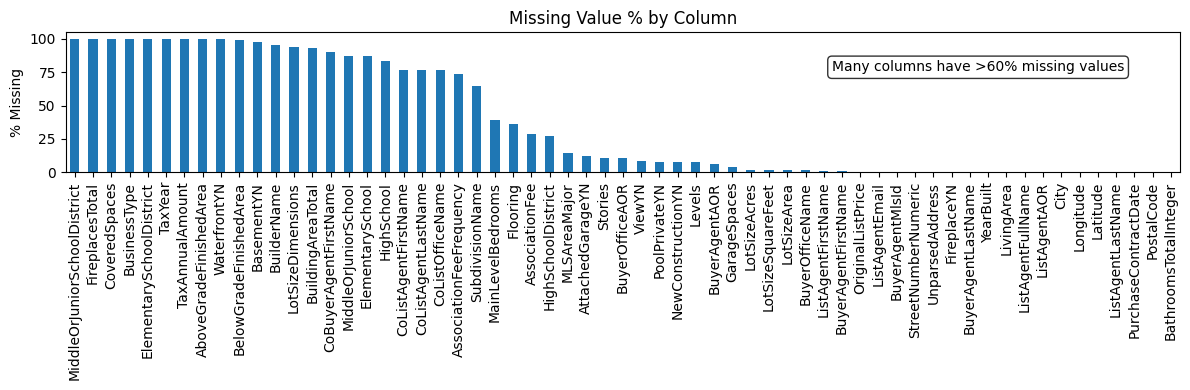

In [50]:
# distribution of missing values across all the columns
missing_pct = data.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind='bar', figsize=(12, 4))
plt.ylabel('% Missing')
plt.title('Missing Value % by Column')
plt.text(
    0.95, 0.80,
    'Many columns have >60% missing values',
    transform=plt.gca().transAxes,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)
plt.tight_layout(); plt.show()

### Initial Cleaning

In [51]:
# columns missing more than 60% of their data
more_then_60_missing = [col for col in data.columns if data[col].isnull().mean() >= 0.60]

# irrelevant admin columns
admin_keywords = ['Agent', 'Office', 'Listing', 'Address', 'Email', 
                  'AOR', 'Mls', 'MLS', 'Buyer', 'Flooring', 'Street','Association', 'Contract']
admin_cols = [col for col in data.columns if any(keyword in col for keyword in admin_keywords)]

# columns that induce feature leakage (highly correlated with closing price or determined after sale)
leaking_cols =['ListPrice', 'OriginalListPrice', 'DaysOnMarket']

drop_cols = list(set(more_then_60_missing + admin_cols + leaking_cols)) # all the columns that need to be dropped
data.drop(columns=[col for col in drop_cols if col in data.columns], inplace=True) # list comp ensures that even if the col doesn't exist, the code won't break
data.drop(columns = ['StateOrProvince'], inplace=True) # drop redundant StateOrProvince column

In [52]:
# parse CloseDate column 
data['CloseDate'] = pd.to_datetime(data['CloseDate'], errors = 'coerce')
data['CloseMonth'] = data['CloseDate'].dt.to_period('M')

# drop categorical columns with high cardinality, keeping CountyOrParish for longitude and latitude calculations later
categorical_cols = data.select_dtypes(include='object').columns.tolist()
high_card = [col for col in categorical_cols if data[col].nunique() > 15 and col != 'CountyOrParish']
data.drop(columns=high_card, inplace=True)

# impute all missing values in boolean YN columns to False (assuming na means False)
for col in data.columns:
    if col.endswith('YN'):
        data[col] = data[col].fillna(False)

# fillna in GarageSpaces with 0 (assuming na means 0 garage spaces)
data['GarageSpaces'] = data['GarageSpaces'].fillna(0)

# for simplicity, drop MainLevelBedrooms, as we already have BedroomsTotal
data.drop(columns=['MainLevelBedrooms'], inplace=True)

### Creating/Cleaning Training and Testing Splits 

In [53]:
# create training and testing splits
n_months_train = 5 # number of months we will train the models on 
most_recent_month = data['CloseMonth'].max() 
training_months =pd.period_range(end=most_recent_month - 1, periods=n_months_train, freq = 'M')

train_data = data[data['CloseMonth'].isin(training_months)].copy() 
test_data = data[data['CloseMonth'] == most_recent_month].copy() 

In [54]:
# fill in missing values in Latitude and Longitude with county specific medians
for coord in ['Latitude', 'Longitude']:
    if coord in train_data.columns:
        county_medians = train_data.groupby('CountyOrParish')[coord].median()
        global_median = train_data[coord].median()

        # fillna with county specific medians
        train_data[coord] = train_data[coord].fillna(train_data['CountyOrParish'].map(county_medians))
        test_data[coord] = test_data[coord].fillna(test_data['CountyOrParish'].map(county_medians))

        # fillna with global medians if county does not exist
        train_data[coord] = train_data[coord].fillna(global_median)
        test_data[coord] = test_data[coord].fillna(global_median)

# drop CountyOrParish, since it has high cardinality
train_data = train_data.drop(columns=['CountyOrParish'])
test_data = test_data.drop(columns=['CountyOrParish'])

In [55]:
# derive any missing LotSizeSquareFeet values using LotSizeAcres
for df in [train_data, test_data]:
    acres_available = df['LotSizeAcres'].notna() & df['LotSizeSquareFeet'].isna()

    # derive LotSizeSquareFeet
    df.loc[acres_available, 'LotSizeSquareFeet'] = df.loc[acres_available, 'LotSizeAcres'] * 43560

# drop LotSizeArea and LotSizeAcres, as we will use LotSizeSquareFeet across the board
train_data = train_data.drop(columns=['LotSizeArea', 'LotSizeAcres'])
test_data = test_data.drop(columns=['LotSizeArea', 'LotSizeAcres'])

# fillna in Stories, LivingArea, BathroomsTotalInteger, YearBuilt, and LotSizeSquareFeet
# with median (computed from training set and applied to test set)
for col in ['Stories', 'LivingArea', 'BathroomsTotalInteger', 'YearBuilt', 'LotSizeSquareFeet']:
    median = train_data[col].median()
    train_data[col] = train_data[col].fillna(median)
    test_data[col] = test_data[col].fillna(median)

In [56]:
# drop CloseMonth in both splits
train_data.drop(columns=['CloseMonth', 'CloseDate'], inplace = True)
test_data.drop(columns=['CloseMonth', 'CloseDate'], inplace=True)

### Removing Outliers

In [57]:
# remove outliers by capping the data at 99th percetile in important columns
for col in ['ClosePrice', 'LivingArea', 'BedroomsTotal', 'LotSizeSquareFeet', 'BathroomsTotalInteger']:
    cap = train_data[col].quantile(0.99)
    train_data = train_data[train_data[col] <= cap]
    test_data = test_data[test_data[col] <= cap]

### Saving Unscaled Splits

In [58]:
# change into data directory
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange/data')

# save csv files
train_data.to_csv('train_set_unscaled.csv', index=False)
test_data.to_csv('test_data_unscaled.csv', index=False)

# change directories back
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange')

### Scaling Numeric Features

In [59]:
## get numeric features
numeric_cols = train_data.select_dtypes(include='number').columns.tolist()
exclude_cols = ['ClosePrice'] + [col for col in numeric_cols if col.endswith('YN')] # exclude target variable, and any bool YN columns as a safety check
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

scaler = StandardScaler()

# fit scaler on training data, then apply fit to test data
train_data[numeric_cols] = scaler.fit_transform(train_data[numeric_cols])
test_data[numeric_cols] = scaler.transform(test_data[numeric_cols])

### Saving Scaled Splits

In [ ]:
# change into data directory
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange/data')

# save csv files
train_data.to_csv('train_set_scaled.csv', index=False)
test_data.to_csv('test_data_scaled.csv', index=False)

# change directories back
os.chdir('/Users/aadityaparanjape/Downloads/IDX Exchange')